# CerradoCoffeeLeaf: An In-the-Wild Dataset for Coffee Leaf Disease Recognition and Cross-Dataset Generalization

- Otávio Massanobu de Souza Oda 
- Pedro Ivo Vieira Good God -- pedro.god@ufv.br  
- Leandro Henrique Furtado Pinto Silva -- leandro.furtado@ufv.br  
- João Fernando Mari -- [joaofmari.github.io](joaofmari.github.io) 


Institute of Exact and Technological Sciences - Federal University of Viçosa, Rio Paranaíba, MG, Brazil \
Institute of Agricultural Sciences – Federal University of Viçosa, Rio Paranaíba, MG, Brazil

## Importing the libraries
---

In [746]:
import sys
import os
import argparse
import random
import time
import pickle
import datetime

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import PIL
from PIL import Image
import scipy.spatial.distance as spd
import sklearn
from sklearn import metrics, model_selection, preprocessing

import torch
from torch import nn, optim

import torchvision
from torchvision import transforms, models, datasets, utils

# Local imports
from early_stopping import EarlyStopping
from models import create_model
from data_aug_3 import get_da

In [ ]:
# To calculate the total experiment time.
time_exp_start = time.time() 

## Configuring GPU...
---

In [748]:
print('Configuring GPU...')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice: {DEVICE}')

if str(DEVICE) != 'cuda':
    print('CUDA not available. Finishing the program...')
    print('\nDone!\n\n')
    sys.exit()

Configuring GPU...

Device: cuda


## Argument parsing
---

In [ ]:
parser = argparse.ArgumentParser()
# Main
parser.add_argument('--arch', help='CNN architecture.', type=str, default='alexnet', )
parser.add_argument('--optim', help="Hyperparameter optimization: ['none', 'grid', 'random'].", type=str, default='none', )
parser.add_argument('--optim_os', help="Hyperparameter optimization for open set: ['none', 'grid', 'random'].", type=str, default='none', )
# Trainig Datasets
parser.add_argument('--ds', help='Dataset name.', type=str, default='UFVCoffeeLeaf')
parser.add_argument('--ds_split', help='How ds is split: ["train-val-test", "train-test", "no-split"].', type=str, default='no-split')
parser.add_argument('--ds1', help='Dataset name.', type=str, default='none')
parser.add_argument('--ds1_split', help='How ds is split: ["train-val-test", "train-test", "no-split"].', type=str, default='no-split')
parser.add_argument('--ds2', help='Dataset name.', type=str, default='none')
parser.add_argument('--ds2_split', help='How ds is split: ["train-val-test", "train-test", "no-split"].', type=str, default='no-split')
parser.add_argument('--ds3', help='Dataset name.', type=str, default='none')
parser.add_argument('--ds3_split', help='How ds is split: ["train-val-test", "train-test", "no-split"].', type=str, default='no-split')
# Test Datasets
parser.add_argument('--ds_test', help='Test dataset name.', type=str, default='UFVCoffeeLeaf')
parser.add_argument('--ds_test_split', help='How test ds is split: ["train-val-test", "train-test", "no-split"].', type=str, default='no-split')
parser.add_argument('--ds1_test', help='Test dataset name.', type=str, default='none')
parser.add_argument('--ds1_test_split', help='How test ds is split: ["train-val-test", "train-test", "no-split"].', type=str, default='no-split')
parser.add_argument('--ds2_test', help='Test dataset name.', type=str, default='none')
parser.add_argument('--ds2_test_split', help='How test ds is split: ["train-val-test", "train-test", "no-split"].', type=str, default='no-split')
parser.add_argument('--ds3_test', help='Test dataset name.', type=str, default='none')
parser.add_argument('--ds3_test_split', help='How test ds is split: ["train-val-test", "train-test", "no-split"].', type=str, default='no-split')
parser.add_argument('--overlap', help='Select only overlapping classes?', default=True, action=argparse.BooleanOptionalAction)
# Aux
parser.add_argument('--sm', help='Save the model?', default=True, action=argparse.BooleanOptionalAction)
parser.add_argument('--seed', help='Seed for random number generator.', type=int, default=42)
parser.add_argument('--num_workers', help='Number of available cores.', type=int, default=2)
parser.add_argument('--ec', help='Experiment counter. Used for hp optimization.', type=int, default=0)
parser.add_argument('--debug', help="Is running in debug mode?", required=False, default=False, action=argparse.BooleanOptionalAction)
# Optimizer
parser.add_argument('--optimizer', help="Optimizer. ['SGD', 'Adam'].", type=str, default='Adam')
parser.add_argument('--scheduler', help="Scheduler. ['steplr', 'cossine', 'plateau'].", type=str, default='plateau')
# Hyperparameters 
parser.add_argument('--bs', help='Barch size.', type=int, default=64)
parser.add_argument('--lr', help='Learning rate.', type=float, default=0.0001)
parser.add_argument('--mm', help='Momentum.', type=float, default=0.9)
parser.add_argument('--ss', help='Step size.', type=int, default=5)
### parser.add_argument('--wd', help='Weight decay.', type=float, default=0.1)
parser.add_argument('--ep', help='Number of epochs', type=int, default=200) 
# Fine-tunning
parser.add_argument('--ft', help='Treinamento com fine-tuning.', default=True, action=argparse.BooleanOptionalAction)
# Data augmentation strategy. Ignorado se otimização de hiperparametros
parser.add_argument('--datrain', help='Data augmentation stretegy for training. 0 = no data augmentation.',  type=int, default=0)
parser.add_argument('--daval', help='Data augmentation stretegy for validating. 0 = no data augmentation.',  type=int, default=0)
parser.add_argument('--datest', help='Data augmentation stretegy for testing. 0 = no data augmentation.',  type=int, default=0)
# Usa BCELoss em problemas com duas classes. Se False, usa CrossEntropyLoss para qualquer número de classes
parser.add_argument('--bce', help='Usa Binary Cross Entropy em problemas com duas classes.', default=True, action='store_true')
# Explainable AI
parser.add_argument('--xai', help='Perform eXplainable AI analysis.', default=False, action=argparse.BooleanOptionalAction)
# Early stopping
parser.add_argument('--es', help='Use early stopping.', default=True, action=argparse.BooleanOptionalAction)
parser.add_argument('--patience', help='Patience for early stopping.', type=int, default=21) # Use 21, if plateau
parser.add_argument('--delta', help='Delta for early stopping', type=float, default=0.0001)

# ***** IMPORTANT!!! *****
# Comment out this line after generating the .py file!
# *************************
sys.argv = ['-f']

# Processes the arguments provided on the command line
args = parser.parse_args()

# Performing Training...
# If False, only inference is performed (it is necessary to have a trained model in the EXP_PATH folder).
TRAIN = True

# SPLIT_VAL: Split the TRAINING set in TRAINING and VALIDATION SET.
# If False, the test set is used for validation.
# (Does not apply to 'train-val-test'). If in doubt, keep True.
SPLIT_VAL = True # True

In [750]:
if args.optim != 'none':
    # If hp optimization, do not save model.
    args.sm = False
    # If you want to fix a da strategy when hp optim, unncoment...
    ### args.da = 0
    # if hp optimization, always ignore XAI.
    args.xai = False
    # If hp optimization, do not perform Open-set classification
    ### args.os = 'none'

### Save arguments

In [751]:
def get_versions():
    str = ''
    str += f'\nNumPy: {np.__version__}'
    str += f'\nMatplotlib: {matplotlib.__version__}'
    ### str += f'\nPandas: {pd.__version__}'
    str += f'\nPIL: {PIL.__version__}'
    str += f'\nScikit-learn: {sklearn.__version__}'
    str += f'\nPyTorch: {torch.__version__}'
    str += f'\nTorchvision: {torchvision.__version__}'

    return str

args_str = ''
for arg in vars(args):
    args_str += f'\n{arg}: {getattr(args, arg)}'
    print(f'{arg}: {getattr(args, arg)}')

arch: resnet50
optim: none
optim_os: none
ds: UFVCoffeeLeaf
ds_split: no-split
ds1: RoCoLe
ds1_split: no-split
ds2: none
ds2_split: no-split
ds3: none
ds3_split: no-split
ds_test: UFVCoffeeLeaf
ds_test_split: no-split
ds1_test: RoCoLe
ds1_test_split: no-split
ds2_test: none
ds2_test_split: no-split
ds3_test: none
ds3_test_split: no-split
overlap: False
sm: True
seed: 42
num_workers: 2
ec: 11
debug: True
optimizer: Adam
scheduler: plateau
bs: 64
lr: 0.0001
mm: 0.9
ss: 5
ep: 2
ft: True
datrain: 2
daval: 1
datest: 1
bce: True
xai: False
es: True
patience: 21
delta: 0.0001


## CUSTOMIZED DATASET
---

In [ ]:
class CustomDataset(torch.utils.data.Dataset):

    def __init__(self, path_list, label_list, transforms=None):
        self.path_list = path_list
        self.label_list = label_list
        self.transforms = transforms

        self.num_gray = 0
        self.num_ms = 0

    def __len__(self):
        # Number of images.
        return len(self.path_list)

    def __getitem__(self, idx):
        # Path to the image.
        path = self.path_list[idx]
        # Loads the image.
        image = Image.open(self.path_list[idx]) 

        if np.array(image).ndim != 3:
            # Converts grayscale images (single-channel) to RGB
            image = image.convert(mode='RGB')
            self.num_gray = self.num_gray + 1
        elif np.array(image).shape[2] > 3:
            # Handles images with an alpha (transparency) channel (4 channels) by converting them to RGB (3 channels)
            image = image.convert(mode='RGB')

            self.num_ms = self.num_ms + 1

        # Image label (class)
        label = self.label_list[idx]

        # Applies transformations to the image (data augmentation)
        if self.transforms:
            image = self.transforms(image)

        # Returns the image, the image label (class), and the path to the image file.
        return (image, label, path)   

## CONFIGURING DATASETS
---

In [ ]:
def config_ds(ds_name):
    # Path to the folder that contains ALL your datasets
    DS_PATH_MAIN = os.path.expanduser('~/Datasets/')

    # The dataset folder must have the same name as the dataset.
    # Adjust the path, inside the dataset folder, to the folder that contains the images (no-split),
    # or to the folder that contains the 'train', 'test', and, if it exists, 'val' folders.
    if ds_name == 'BRACOL': # no-split
        ds_path = os.path.join(DS_PATH_MAIN, ds_name, 'BRACOL_ok')
    elif ds_name == 'JMuBEN': # no-split
        ds_path = os.path.join(DS_PATH_MAIN, ds_name, 'JMuBEN_full')
    elif ds_name == 'RoCoLe': # no-split
        ds_path = os.path.join(DS_PATH_MAIN, ds_name, 'RoCoLe_ok')
    elif ds_name == 'UFVCoffeeLeaf': # no-split
        ds_path = os.path.join(DS_PATH_MAIN, ds_name, 'UFVCoffeeLeaf_v01', 'Dataset_1024')
    
    return ds_path

In [ ]:
def prepare_dataset_list(ds, ds_split, 
                         ds1=None, ds1_split=None, 
                         ds2=None, ds2_split=None, 
                         ds3=None, ds3_split=None):
    """
    Builds lists of datasets, paths, and splits based on args.
    
    Args:
        args: object with ds, ds1, ds2, ds3, ds_split, ds1_split, ds2_split, ds3_split.
        config_ds: function that returns dataset path given a dataset name.
    
    Returns:
        DS_LIST: list of dataset names
        DS_PATH: list of dataset paths
        DS_SPLIT: list of split names
        ds_path_str: single string with dataset names joined by '-'
    """
    DS_LIST = []
    DS_PATH = []
    DS_SPLIT = []

    DS_LIST.append(ds)
    DS_PATH.append(config_ds(ds))
    DS_SPLIT.append(ds_split)
    ### print(f'Dataset: {ds}')
    ### print(f'Dataset Path: {DS_PATH[0]}')

    if ds1 != 'none':
        DS_LIST.append(ds1)
        DS_PATH.append(config_ds(ds1))
        DS_SPLIT.append(ds1_split)

    if ds2 != 'none':
        DS_LIST.append(ds2)
        DS_PATH.append(config_ds(ds2))
        DS_SPLIT.append(ds2_split)

    if ds3 != 'none':
        DS_LIST.append(ds3)
        DS_PATH.append(config_ds(ds3))
        DS_SPLIT.append(ds3_split)

    print(DS_LIST)
    print(DS_PATH)
    print(DS_SPLIT)

    ds_path_str = '-'.join(DS_LIST)
    print(ds_path_str)

    return DS_LIST, DS_PATH, DS_SPLIT, ds_path_str

In [755]:
print('\nPreparing training dataset list...')
DS_LIST, DS_PATH, DS_SPLIT, ds_path_str = prepare_dataset_list(
    args.ds, args.ds_split,
    args.ds1, args.ds1_split,
    args.ds2, args.ds2_split,
    args.ds3, args.ds3_split
)

print('\nPreparing test dataset list...')
DS_LIST_TEST, DS_PATH_TEST, DS_SPLIT_TEST, ds_path_test_str = prepare_dataset_list(
    args.ds_test, args.ds_test_split,
    args.ds1_test, args.ds1_test_split,
    args.ds2_test, args.ds2_test_split,
    args.ds3_test, args.ds3_test_split
)


Preparing training dataset list...
['UFVCoffeeLeaf', 'RoCoLe']
['/home/joao/Datasets/UFVCoffeeLeaf/UFVCoffeeLeaf_v01/Dataset_1024', '/home/joao/Datasets/RoCoLe/RoCoLe_ok']
['no-split', 'no-split']
UFVCoffeeLeaf-RoCoLe

Preparing test dataset list...
['UFVCoffeeLeaf', 'RoCoLe']
['/home/joao/Datasets/UFVCoffeeLeaf/UFVCoffeeLeaf_v01/Dataset_1024', '/home/joao/Datasets/RoCoLe/RoCoLe_ok']
['no-split', 'no-split']
UFVCoffeeLeaf-RoCoLe


## Saving the experiments
---

In [ ]:
# Main folder to store ALL experiments
if args.optim != 'none':
    # If hyperparameter optimization
    EXP_PATH_MAIN = f'exp_hp'
elif args.debug == True:
    # If debug mode
    EXP_PATH_MAIN = f'exp_debug'
else:
    # If normal experiment execution 
    EXP_PATH_MAIN = f'exp'

# Check if EXP_PATH_MAIN exists. If not, create it.
if not os.path.isdir(EXP_PATH_MAIN): os.mkdir(EXP_PATH_MAIN)

# Momentum. Only if optmizer is SGD
mm_str = f'-mm_{args.mm}' if args.optimizer == 'SGD' else ''
# Step size. Only if scheduler is steplr
ss_str = f'-ss_{args.ss}' if args.scheduler == 'steplr' else ''

# String containing the hyperparameter values of this experiment.
hp_str = f'-bs_{args.bs}-lr_{args.lr}-op_{args.optimizer}{mm_str}-sh_{args.scheduler}{ss_str}-epochs_{args.ep}'

# Adjusts for the folder name
hp_optim = '' if args.optim == 'none' else f'-{args.optim}'
ov_str = 'ov' if args.overlap else 'nonov'

# Folder that will store the results of this training
EXP_PATH = os.path.join(EXP_PATH_MAIN, f'({ds_path_str})-({ds_path_test_str})-{ov_str}-{args.arch}{hp_optim}-datrain_{args.datrain}-daval_{args.daval}{hp_str}')
print(f'Exp path: {EXP_PATH}')

# Check if EXP_PATH exists. If not, create it.
if not os.path.exists(EXP_PATH): os.mkdir(EXP_PATH)

else:
    # If the folder already exists, it is possible the experiment should (or shouldn't) be complete.
    # We check this by verifying whether the file 'done.txt' is in the folder.
    # The file 'done.txt' is only created when the experiment has fully finished.
    if os.path.exists(os.path.join(EXP_PATH, 'done.txt')):
        if args.optim != 'none':
            print('Model already trained!  Exiting...')
            sys.exit()
        else:
            # The folder exists and the experiment is done.
            print('Model already trained! Performing prediction...')
            TRAIN = False

Exp path: exp_debug/(UFVCoffeeLeaf-RoCoLe)-(UFVCoffeeLeaf-RoCoLe)-nonov-resnet50-datrain_2-daval_1-bs_64-lr_0.0001-op_Adam-sh_plateau-epochs_2


In [757]:
if TRAIN:
    with open(os.path.join(EXP_PATH, 'general_report.txt'), 'w') as model_file:
        model_file.write('\nArguments:')
        ### model_file.write(str(args.__str__()))
        model_file.write(args_str)
        model_file.write('\n\nPackage versions:')
        model_file.write(str(get_versions()))

# Reprodutibility configurations
---

In [ ]:
def set_seed(seed):
    """Sets the random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # If you use multi-GPU

    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # For CUDA >= 10.2

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    if args.arch != 'alexnet':
        torch.use_deterministic_algorithms(True)

# Reset the seed.
set_seed(args.seed)

## Preparing the dataset
---

### Setting data transformations (data augmentation)

In [ ]:
# ImageNet mean and standard deviation.
DS_MEAN = [0.485, 0.456, 0.406]
DS_STD =  [0.229, 0.224, 0.225]

In [ ]:
data_transforms_train = get_da(args.datrain, DS_MEAN, DS_STD)
data_transforms_val = get_da(args.daval, DS_MEAN, DS_STD)
data_transform_test = get_da(args.datest, DS_MEAN, DS_STD)

## Datasets and dataloaders
---

### Dataset split

In [ ]:
def ds_split(ds_path, mode='train-val-test'):

    # **** train-val-test ****
    # -----------------------------------------------------------------
    if mode == 'train-val-test':
        class_names = os.listdir(os.path.join(ds_path, 'train'))
        class_names.sort()
        ### num_classes = len(class_names)

        # Original training set
        X_train = []
        y_train = []

        for class_ in class_names:
            # Sorted list of files (images) in each folder
            path_list_ = os.listdir(os.path.join(ds_path, 'train', class_))
            path_list_.sort()
            # Iterates over the files in the current folder (class)
            for path_image in path_list_:
                file_path = os.path.join(ds_path, 'train', class_, path_image)
                X_train.append(file_path)
                y_train.append(class_)

        # Original test set
        X_test = []
        y_test = []

        for class_ in class_names:
            # Sorted list of files (images) in each folder
            path_list_ = os.listdir(os.path.join(ds_path, 'test', class_))
            path_list_.sort()
            # Iterates over the files in the current folder (class)
            for path_image in path_list_:
                file_path = os.path.join(ds_path, 'test', class_, path_image)
                X_test.append(file_path)
                y_test.append(class_)

        # Original validation set
        X_val = []
        y_val = []

        for class_ in class_names:
            # Sorted list of files (images) in each folder
            path_list_ = os.listdir(os.path.join(ds_path, 'val', class_))
            path_list_.sort()
            # Iterates over the files in the current folder (class)
            for path_image in path_list_:
                file_path = os.path.join(ds_path, 'val', class_, path_image)
                X_val.append(file_path)
                y_val.append(class_)

        # Splits the training set for validation
        le = preprocessing.LabelEncoder()
        le.fit(class_names)
        y_train_idx = le.transform(y_train)
        y_val_idx = le.transform(y_val)
        y_test_idx = le.transform(y_test)

    # **** train-test ****
    # -----------------------------------------------------------------
    elif mode == 'train-test':
        class_names = os.listdir(os.path.join(ds_path, 'train'))
        class_names.sort()
        ### num_classes = len(class_names)

        # Original training set
        X_train_ = []
        y_train_ = []

        for class_ in class_names:
            # Sorted list of files (images) in each folder
            path_list_ = os.listdir(os.path.join(ds_path, 'train', class_))
            path_list_.sort()
            # Iterates over the files in the current folder (class)
            for path_image in path_list_:
                file_path = os.path.join(ds_path, 'train', class_, path_image)
                X_train_.append(file_path)
                y_train_.append(class_)

        # Original test set
        X_test = []
        y_test = []

        for class_ in class_names:
            # Sorted list of files (images) in each folder
            path_list_ = os.listdir(os.path.join(ds_path, 'test', class_))
            path_list_.sort()
            # Iterates over the files in the current folder (class)
            for path_image in path_list_:
                file_path = os.path.join(ds_path, 'test', class_, path_image)
                X_test.append(file_path)
                y_test.append(class_)

        # Splits the training set for validation
        le = preprocessing.LabelEncoder()
        le.fit(class_names)
        y_train_idx = le.transform(y_train_)
        y_test_idx = le.transform(y_test)

        if SPLIT_VAL == True:
            VAL_SIZE  = 0.2

            X_train, X_val, y_train_idx, y_val_idx = model_selection.train_test_split(
                X_train_, 
                y_train_idx, 
                test_size=VAL_SIZE, 
                stratify=y_train_idx, 
                random_state=42
            )

        else:
            X_train = X_train_
            X_val = X_test
            y_train_idx = y_train_idx
            y_val_idx = y_test_idx

    # **** no-split ****
    # -----------------------------------------------------------------
    elif mode == 'no-split':
        class_names = os.listdir(ds_path)
        class_names.sort()
        ### num_classes = len(class_names)

        # Original training set
        X_ = []
        y_ = []

        for class_ in class_names:
            # Sorted list of files (images) in each folder
            path_list_ = os.listdir(os.path.join(ds_path, class_))
            path_list_.sort()
            # Iterates over the files in the current folder (class)
            for path_image in path_list_:
                file_path = os.path.join(ds_path, class_, path_image)
                X_.append(file_path)
                y_.append(class_)

        # Splits the training set for validation
        le = preprocessing.LabelEncoder()
        le.fit(class_names)
        y_idx = le.transform(y_)

        # Splits the test set
        TEST_SIZE  = 0.2
        X_train_, X_test, y_train_idx_, y_test_idx = model_selection.train_test_split(
            X_, 
            y_idx, 
            test_size=TEST_SIZE, 
            stratify=y_idx, 
            random_state=42
        )

        if SPLIT_VAL == True:
            VAL_SIZE_ = 0.2
            VAL_SIZE = VAL_SIZE_

            X_train, X_val, y_train_idx, y_val_idx = model_selection.train_test_split(
                X_train_, 
                y_train_idx_, 
                test_size=VAL_SIZE, 
                stratify=y_train_idx_, 
                random_state=42
            )

        else:
            X_train = X_train_
            X_val = X_test
            y_train_idx = y_train_idx_
            y_val_idx = y_test_idx

    # Get the class names from the LabelEncoder object.
    class_names_ = le.classes_
    # print(class_names_)
    # print(class_names)

    return X_train, X_val, X_test, y_train_idx, y_val_idx, y_test_idx, class_names_.tolist()

### CROSS-DATASET ANALYSIS


In [ ]:
def merge_class_indices(x, class_names_x, y, class_names_y):
    """
    Merges class indices from two datasets, ensuring that the class names are consistent.
    Args:
        x (list): List of file paths or data points from the first dataset.
        class_names_x (list): List of class names corresponding to the first dataset.
        y (list): List of class indices from the second dataset.
        class_names_y (list): List of class names corresponding to the second dataset.
    Returns:
        tuple: A tuple containing:
            - xy (np.ndarray): A concatenated array of x and adjusted y indices.
            - class_names_xy (list): A sorted list of unique class names from both datasets.
    """
    # Create a dictionary with the mappings of the existing classes
    class_mapping = {name: idx for idx, name in enumerate(class_names_x)}
    
    # Adjust the indices of y to maintain consistency
    new_y = []
    for idx in y:
        class_name = class_names_y[idx]
        if class_name not in class_mapping:
            class_mapping[class_name] = len(class_mapping)
        new_y.append(class_mapping[class_name])
    
    # Create the combined list of classes
    class_names_xy = [name for name, _ in sorted(class_mapping.items(), key=lambda item: item[1])]
    
    # Concatenate the adjusted x and y arrays
    xy = np.concatenate((x, np.array(new_y)))
    
    return xy, class_names_xy

In [763]:
def count_images_per_class(X, y_idx, class_names):
    """
    Counts number of images per class index and prints with class names.
    
    Args:
        X: list of image paths
        y_idx: list of class indices (after filtering)
        class_names: list of class names in new index order
    """
    # Count
    counts = {}
    for idx in y_idx:
        if idx in counts:
            counts[idx] += 1
        else:
            counts[idx] = 1

    # Print nicely, in index order
    ### print("Class counts:")
    for idx, name in enumerate(class_names):
        count = counts.get(idx, 0)
        print(f"  [{idx}] {name}: {count}")

In [ ]:
def load_and_merge_datasets(DS_PATH, DS_SPLIT, verbose=True):
    """
    Loads multiple datasets, splits them, merges them and updates class indices.

    Args:
        DS_PATH: list of dataset paths
        DS_SPLIT: list of split names
        ds_split_func: function to split one dataset, e.g., ds_split(path, split)
        merge_class_indices_func: function to merge indices and class names
        verbose: if True, prints debug info

    Returns:
        X_train, X_val, X_test
        y_train_idx, y_val_idx, y_test_idx
        final_class_names
    """
    # Load first dataset
    X_train, X_val, X_test, y_train_idx, y_val_idx, y_test_idx, class_names = ds_split(DS_PATH[0], DS_SPLIT[0])

    if verbose:
        print(f'Loaded: {DS_PATH[0]}')
        print(f'Class names ({len(class_names)}):', class_names)
        print('Train:')
        count_images_per_class(X_train, y_train_idx, class_names)
        print('Val:')
        count_images_per_class(X_val, y_val_idx, class_names)
        print('Test:')
        count_images_per_class(X_test, y_test_idx, class_names)
        
    # Load and merge others
    for ds_path, ds_split_ in zip(DS_PATH[1:], DS_SPLIT[1:]):
        X_train_, X_val_, X_test_, y_train_idx_, y_val_idx_, y_test_idx_, class_names_ = ds_split(ds_path, ds_split_)

        if verbose:
            print('\nLoaded:', ds_path)
            print(f'Class names ({len(class_names_)}):', class_names_)
            print('Train:')
            count_images_per_class(X_train_, y_train_idx_, class_names_)
            print('Val:')
            count_images_per_class(X_val_, y_val_idx_, class_names_)
            print('Test:')
            count_images_per_class(X_test_, y_test_idx_, class_names_)

        # Concatenate samples
        X_train += X_train_
        X_val += X_val_
        X_test += X_test_

        # Merge labels and class names
        y_train_idx, class_names_t = merge_class_indices(y_train_idx, class_names, y_train_idx_, class_names_)
        y_val_idx, class_names_v = merge_class_indices(y_val_idx, class_names, y_val_idx_, class_names_)
        y_test_idx, class_names_te = merge_class_indices(y_test_idx, class_names, y_test_idx_, class_names_)

        if class_names_t != class_names_v or class_names_t != class_names_te:
            print('Warning: Different class names after merging!')

        class_names = class_names_t

    if verbose:
        print('\nUpdated merged dataset:')
        print('-----------------------')
        print(f'Class names ({len(class_names)}):', class_names)
        print('Train:')
        count_images_per_class(X_train, y_train_idx, class_names)
        print('Val:')
        count_images_per_class(X_val, y_val_idx, class_names)
        print('Test:')
        count_images_per_class(X_test, y_test_idx, class_names)

    return X_train, X_val, X_test, y_train_idx, y_val_idx, y_test_idx, class_names

In [765]:
print('Merging training datasets...')
X_train, X_val, _, y_train_idx, y_val_idx, _, class_names = load_and_merge_datasets(
    DS_PATH, DS_SPLIT, verbose=True
)

num_classes = len(class_names)
print(f'Number of classes: {num_classes}')

Merging training datasets...
Loaded: /home/joao/Datasets/UFVCoffeeLeaf/UFVCoffeeLeaf_v01/Dataset_1024
Class names (7): ['ascochyta', 'bacterial_blight', 'cercospora', 'healthy', 'miner', 'phoma', 'rust']
Train:
  [0] ascochyta: 91
  [1] bacterial_blight: 113
  [2] cercospora: 215
  [3] healthy: 65
  [4] miner: 225
  [5] phoma: 26
  [6] rust: 209
Val:
  [0] ascochyta: 23
  [1] bacterial_blight: 28
  [2] cercospora: 54
  [3] healthy: 16
  [4] miner: 56
  [5] phoma: 6
  [6] rust: 53
Test:
  [0] ascochyta: 29
  [1] bacterial_blight: 36
  [2] cercospora: 67
  [3] healthy: 20
  [4] miner: 70
  [5] phoma: 8
  [6] rust: 66

Loaded: /home/joao/Datasets/RoCoLe/RoCoLe_ok
Class names (3): ['healthy', 'red_spider_mite', 'rust']
Train:
  [0] healthy: 506
  [1] red_spider_mite: 106
  [2] rust: 386
Val:
  [0] healthy: 127
  [1] red_spider_mite: 27
  [2] rust: 96
Test:
  [0] healthy: 158
  [1] red_spider_mite: 34
  [2] rust: 120

Updated merged dataset:
-----------------------
Class names (8): ['ascoch

In [766]:
print('Merging test datasets...')
_, _, X_test, _, _, y_test_idx, class_names_test = load_and_merge_datasets(
    DS_PATH_TEST, DS_SPLIT_TEST, verbose=True
)

num_classes = len(class_names)
print(f'Number of classes: {num_classes}')

Merging test datasets...
Loaded: /home/joao/Datasets/UFVCoffeeLeaf/UFVCoffeeLeaf_v01/Dataset_1024
Class names (7): ['ascochyta', 'bacterial_blight', 'cercospora', 'healthy', 'miner', 'phoma', 'rust']
Train:
  [0] ascochyta: 91
  [1] bacterial_blight: 113
  [2] cercospora: 215
  [3] healthy: 65
  [4] miner: 225
  [5] phoma: 26
  [6] rust: 209
Val:
  [0] ascochyta: 23
  [1] bacterial_blight: 28
  [2] cercospora: 54
  [3] healthy: 16
  [4] miner: 56
  [5] phoma: 6
  [6] rust: 53
Test:
  [0] ascochyta: 29
  [1] bacterial_blight: 36
  [2] cercospora: 67
  [3] healthy: 20
  [4] miner: 70
  [5] phoma: 8
  [6] rust: 66

Loaded: /home/joao/Datasets/RoCoLe/RoCoLe_ok
Class names (3): ['healthy', 'red_spider_mite', 'rust']
Train:
  [0] healthy: 506
  [1] red_spider_mite: 106
  [2] rust: 386
Val:
  [0] healthy: 127
  [1] red_spider_mite: 27
  [2] rust: 96
Test:
  [0] healthy: 158
  [1] red_spider_mite: 34
  [2] rust: 120

Updated merged dataset:
-----------------------
Class names (8): ['ascochyta'

In [767]:
print(f'Train/Val. class names ({len(class_names)} classes): {class_names}')
print(f'Test class names ({len(class_names_test)} classes): {class_names_test}')
### print(class_names)
### print(class_names_test)

Train/Val. class names (8 classes): ['ascochyta', 'bacterial_blight', 'cercospora', 'healthy', 'miner', 'phoma', 'rust', 'red_spider_mite']
Test class names (8 classes): ['ascochyta', 'bacterial_blight', 'cercospora', 'healthy', 'miner', 'phoma', 'rust', 'red_spider_mite']


### Filter overlapping and open classes between datasets

In [768]:
def filter_open_classes(
    X_train, y_train_idx,
    X_val, y_val_idx,
    X_test, y_test_idx,
    class_names, class_names_test,
    overlap=True
):
    """
    Filters datasets to keep only overlapping classes.
    
    Args:
        X_train, y_train_idx: Training image paths and labels.
        X_val, y_val_idx: Validation image paths and labels.
        X_test, y_test_idx: Test image paths and labels.
        class_names: Class names for training set.
        class_names_test: Class names for test set.
        overlap: If True, removes classes only in train set.
        
    Returns:
        Filtered X/y for train, val, test; new class names list; new class_to_idx mapping.
    """
    # Find overlapping classes
    train_classes = set(class_names)
    test_classes = set(class_names_test)
    print(f'Train classes ({len(train_classes)}): {train_classes}')
    print(f'Test classes: ({len(test_classes)}): {test_classes}')

    overlap_classes = train_classes.intersection(test_classes)
    
    if not overlap:
        overlap_classes = overlap_classes.union(train_classes - test_classes)
    print(f'Overlapping classes ({len(overlap_classes)}): {overlap_classes}')

    # New class name list and index mapping
    new_class_names = sorted(list(overlap_classes))
    class_to_idx = {}
    for idx, name in enumerate(new_class_names):
        class_to_idx[name] = idx

    # Old index -> name maps
    old_train_name_map = {}
    for idx, name in enumerate(class_names):
        old_train_name_map[idx] = name

    old_test_name_map = {}
    for idx, name in enumerate(class_names_test):
        old_test_name_map[idx] = name

    # Maps from old index to new index
    train_idx_map = {}
    for old_idx, name in old_train_name_map.items():
        if name in overlap_classes:
            train_idx_map[old_idx] = class_to_idx[name]

    test_idx_map = {}
    for old_idx, name in old_test_name_map.items():
        if name in overlap_classes:
            test_idx_map[old_idx] = class_to_idx[name]

    # Filtering helper
    def filter_dataset(X, y, idx_map):
        X_new = []
        y_new = []
        for xi, yi in zip(X, y):
            if yi in idx_map:
                X_new.append(xi)
                y_new.append(idx_map[yi])
        return X_new, y_new

    # Apply
    X_train_new, y_train_new = filter_dataset(X_train, y_train_idx, train_idx_map)
    X_val_new, y_val_new = filter_dataset(X_val, y_val_idx, train_idx_map)
    X_test_new, y_test_new = filter_dataset(X_test, y_test_idx, test_idx_map)

    return (
        X_train_new, y_train_new,
        X_val_new, y_val_new,
        X_test_new, y_test_new,
        new_class_names, class_to_idx
    )

In [ ]:
print('**** BEFORE FILTERING CLASSES ****')
print("Train split:")
count_images_per_class(X_train, y_train_idx, class_names)

print("\nValidation split:")
count_images_per_class(X_val, y_val_idx, class_names)

print("\nTest split:")
count_images_per_class(X_test, y_test_idx, class_names_test)

**** ANTES DE FILTRAR CLASSES ****
Train split:
  [0] ascochyta: 91
  [1] bacterial_blight: 113
  [2] cercospora: 215
  [3] healthy: 571
  [4] miner: 225
  [5] phoma: 26
  [6] rust: 595
  [7] red_spider_mite: 106

Validation split:
  [0] ascochyta: 23
  [1] bacterial_blight: 28
  [2] cercospora: 54
  [3] healthy: 143
  [4] miner: 56
  [5] phoma: 6
  [6] rust: 149
  [7] red_spider_mite: 27

Test split:
  [0] ascochyta: 29
  [1] bacterial_blight: 36
  [2] cercospora: 67
  [3] healthy: 178
  [4] miner: 70
  [5] phoma: 8
  [6] rust: 186
  [7] red_spider_mite: 34


In [770]:
X_train, y_train_idx, X_val, y_val_idx, X_test, y_test_idx, class_names, class_to_idx = \
    filter_open_classes(
        X_train, y_train_idx,
        X_val, y_val_idx,
        X_test, y_test_idx,
        class_names, class_names_test,
        overlap=args.overlap
    )

# To maintain consistency with the original code.
class_names_test = class_names

Train classes (8): {'ascochyta', 'bacterial_blight', 'healthy', 'miner', 'phoma', 'cercospora', 'red_spider_mite', 'rust'}
Test classes: (8): {'ascochyta', 'bacterial_blight', 'healthy', 'miner', 'phoma', 'cercospora', 'red_spider_mite', 'rust'}
Overlapping classes (8): {'ascochyta', 'bacterial_blight', 'healthy', 'miner', 'phoma', 'cercospora', 'red_spider_mite', 'rust'}


In [771]:
print('**** FINAL DATASETS ****')
print("Train split:")
count_images_per_class(X_train, y_train_idx, class_names)

print("\nValidation split:")
count_images_per_class(X_val, y_val_idx, class_names)

print("\nTest split:")
count_images_per_class(X_test, y_test_idx, class_names_test)

**** FINAL DATASETS ****
Train split:
  [0] ascochyta: 91
  [1] bacterial_blight: 113
  [2] cercospora: 215
  [3] healthy: 571
  [4] miner: 225
  [5] phoma: 26
  [6] red_spider_mite: 106
  [7] rust: 595

Validation split:
  [0] ascochyta: 23
  [1] bacterial_blight: 28
  [2] cercospora: 54
  [3] healthy: 143
  [4] miner: 56
  [5] phoma: 6
  [6] red_spider_mite: 27
  [7] rust: 149

Test split:
  [0] ascochyta: 29
  [1] bacterial_blight: 36
  [2] cercospora: 67
  [3] healthy: 178
  [4] miner: 70
  [5] phoma: 8
  [6] red_spider_mite: 34
  [7] rust: 186


### Dataset building

In [ ]:
# Validation and test sets for the TRAINING dataset
train_dataset = CustomDataset(X_train, y_train_idx, transforms=data_transforms_train)
val_dataset   = CustomDataset(X_val,   y_val_idx,   transforms=data_transforms_val)
# Validation and test sets for the TEST dataset
test_dataset  = CustomDataset(X_test,  y_test_idx,  transforms=data_transform_test)

# Checking the number of images in each dataset
print(f'\nNumber of images in each dataset:')
print(len(train_dataset), train_dataset.num_gray, train_dataset.num_ms)
print(len(val_dataset), val_dataset.num_gray, val_dataset.num_ms)
print(len(test_dataset), test_dataset.num_gray, test_dataset.num_ms)


Number of images in each dataset:
1942 0 0
486 0 0
608 0 0


In [ ]:
# Size of the training and validation sets (number of images).
train_size = len(train_dataset)
val_size = len(val_dataset)
test_size = len(test_dataset)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

1942
486
608


### Dataloaders building

In [ ]:
# Dataloaders for the TRAINING dataset
dataloader_train = torch.utils.data.DataLoader(train_dataset, 
                                               batch_size=args.bs, 
                                               num_workers=args.num_workers,
                                               shuffle=True,
                                              )

dataloader_val = torch.utils.data.DataLoader(val_dataset,
                                             batch_size=args.bs, 
                                             num_workers=args.num_workers,
                                             shuffle=False,
                                            )

dataloader_test = torch.utils.data.DataLoader(test_dataset,
                                              batch_size=args.bs, 
                                              num_workers=args.num_workers,
                                              shuffle=False,
                                             )

## Visualizing a batch of images
---

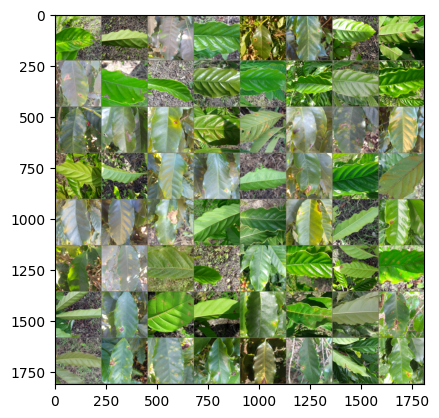

In [ ]:
def save_batch(images_batch):
    """ Save one batch of images in a grid.

    References
    ----------
    * https://discuss.pytorch.org/t/simple-way-to-inverse-transform-normalization/4821/3
    * https://pub.towardsai.net/image-classification-using-deep-learning-pytorch-a-case-study-with-flower-image-data-80a18554df63
    """

    # Unnormalize all channels (ImageNet weights)
    for t, m, s in zip(images_batch, DS_MEAN, DS_STD):
        t.mul_(s).add_(m)
        # The normalize code -> t.sub_(m).div_(s)

    images_batch_np = images_batch.numpy()
    fig_obj = plt.imshow(np.transpose(images_batch_np, (1, 2, 0)))
    
    # Saves the figure to disk
    plt.savefig(os.path.join(EXP_PATH, 'sample_batch.png')) 
    plt.savefig(os.path.join(EXP_PATH, 'sample_batch.pdf')) 

if TRAIN:
    items = iter(dataloader_train)
    image, label, *_ = next(items)

    save_batch(utils.make_grid(image))

## Initializing the model
---

In [ ]:
if TRAIN:
    print('\n>> Initializing the model...')

    model, input_size, _ = create_model(args.arch, args.ft, num_classes, args.bce)

    # Sends the model to the GPU
    model = model.to(DEVICE) 
    # Prints the model
    ### print(str(model))

    # Saves the network model to a .txt file
    with open(os.path.join(EXP_PATH, 'model.txt'), 'w') as model_file:
        model_file.write(str(model))


>> Inicializando o modelo...

Model: ResNet (resnet50)


## Loss function and optimizer
---

In [ ]:
if TRAIN:
    # Loss function (criterion)
    if num_classes > 2 or args.bce == False:
        # Classificação com mais de duas classes.
        criterion = nn.CrossEntropyLoss()
        
    else:
        criterion = nn.BCEWithLogitsLoss()
        print('criterion = nn.BCEWithLogitsLoss()')

    # Otimizador
    if args.optimizer == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=args.lr, momentum=args.mm)

    elif args.optimizer == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=args.lr)

    print(criterion)
    print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


### Scheduler

In [ ]:
if TRAIN:
    if args.scheduler == 'plateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, )
        print(scheduler)

    elif args.scheduler == 'cossine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, 
            T_max=len(dataloader_train), 
            eta_min=0,
            last_epoch=-1
        )
        print(scheduler)

    elif args.scheduler ==  'steplr':
        # Step size of the learning rate
        if args.ss != 0:
            # https://pytorch.org/docs/stable/_modules/torch/optim/lr_scheduler.html#StepLR
            scheduler = optim.lr_scheduler.StepLR(optimizer, 
                                                  step_size=args.ss)
            
            print(scheduler)

    else:
        print('No LR scheduler...')

## Training the model
---

In [ ]:
if TRAIN:
    print('\n>> Training the model...')

    # Total training time (training and validation)
    time_total_start = time.time()

    # List of training losses (loss) and accuracies (accuracy) for each epoch.
    train_loss_list = []
    train_acc_list = []
    # List of validation losses (loss) and accuracies (accuracy) for each epoch.
    val_loss_list = []
    val_acc_list = []
    # List of learning rates for each epoch.
    lr_list = []

    if args.es:
        early_stopping = EarlyStopping(patience=args.patience, delta=args.delta)

    for epoch in range(args.ep):
        # =====================================================================
        # TRAINING
        # =====================================================================
        # Start timing for this epoch
        time_epoch_start = time.time()

        # Losses in this epoch
        train_loss_epoch = 0.
        # Number of samples correctly classified in this epoch
        train_num_hits_epoch = 0  

        # Enable the model for training mode
        model.train() 

        # Iterate along the batches of the TRAINING SET
        # ---------------------------------------------
        for i, (inputs, labels, *_) in enumerate(dataloader_train):
            # Sends the data to the GPU
            inputs = inputs.to(DEVICE) 
            labels = labels.to(DEVICE) 

            # Zeros the gradient parameters
            optimizer.zero_grad() 

            # FORWARD
            # ------>
            # Enable gradient computation
            torch.set_grad_enabled(True) 
            # Model output
            outputs = model(inputs) 

            if num_classes == 2 and args.bce:
                # Calculate probabilities
                # https://discuss.pytorch.org/t/bceloss-vs-bcewithlogitsloss/33586/27
                outputs_prob = torch.sigmoid(outputs) 
                preds = (outputs_prob > 0.5).float().squeeze()

                # Calculates the loss
                loss = criterion(outputs.squeeze(), labels.float())

            else:
                # 'outputs' are in percentages. Take the maximum values as the answers.
                # Ex: batch=3 with 2 classes, then preds = [1, 0, 1]
                preds = torch.argmax(outputs, dim=1).float() 

                # Calculates the loss
                loss = criterion(outputs, labels)

            # BACKWARD
            # <-------
            loss.backward() 

            # Atualiza o gradiente 
            optimizer.step()

            # Updates the epoch loss. The loss of this batch, multiplied by the number of samples in this batch (to get the total loss for the epoch).
            train_loss_epoch += float(loss.item()) * inputs.size(0) 

            # Updates the number of correctly classified samples in this epoch.
            train_num_hits_epoch += torch.sum(preds == labels.data) 

        train_loss_epoch /= len(train_dataset)
        train_acc_epoch = float(train_num_hits_epoch.double() / len(train_dataset))

        # Store loss and accuracy in lists
        train_loss_list.append(train_loss_epoch)
        train_acc_list.append(train_acc_epoch)

        # =====================================================================
        # VALIDATION
        # =====================================================================
        model.eval() 

        # Loss in this epoch
        val_loss_epoch = 0. 
        # Number of samples correctly classified in this epoch
        val_num_hits_epoch = 0 
        
        # Iterate along the batches of the VALIDATION SET
        # -----------------------------------------------
        for i, (inputs, labels, *_) in enumerate(dataloader_val):
            # Sends the data to the GPU
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            # Zero the gradient before computing the loss
            optimizer.zero_grad() 

            # Disable gradient, since the parameters do not change in the validation step
            torch.set_grad_enabled(False) 

            # Generates the output from the input
            outputs = model(inputs) 

            if num_classes == 2 and args.bce:
                # Calculate probabilities
                # https://discuss.pytorch.org/t/bceloss-vs-bcewithlogitsloss/33586/27
                outputs_prob = torch.sigmoid(outputs) 
                preds = ((outputs_prob > 0.5).float()).squeeze()

                # Calculates the loss
                loss = criterion(outputs.squeeze(), labels.float())

            else:
                # Returns the highest prediction.
                preds = torch.argmax(outputs, dim=1).float()

                # Calculates the loss
                loss = criterion(outputs, labels) 

            # Accumulated loss in the epoch
            val_loss_epoch += float(loss.item()) * inputs.size(0)

            # Accumulated correct predictions in the epoch
            val_num_hits_epoch += torch.sum(preds == labels.data)

        # Adjusts the learning rate according to the scheduler.
        if args.scheduler == 'steplr' and args.ss != 0:
            scheduler.step() 
        
        elif args.scheduler == 'cossine' and epoch >= 10:
            scheduler.step()

        elif args.scheduler == 'plateau':
            scheduler.step(val_loss_epoch)

        # Gets the learning rate in this epoch.
        lr_epoch = optimizer.param_groups[0]['lr']
        lr_list.append(lr_epoch)
            
        # Calculates the loss and accuracy for the entire validation set
        val_loss_epoch /= len(val_dataset)
        val_acc_epoch = float(val_num_hits_epoch.double() / len(val_dataset))

        # Inserting the loss and accuracy into the arrays
        val_loss_list.append(val_loss_epoch)
        val_acc_list.append(val_acc_epoch)

        if args.es:
            # Applies early stopping
            early_stopping(val_loss_epoch, model, epoch)
            
            if early_stopping.early_stop:
                print(f'Early stopping in epoch {early_stopping.best_epoch}!')
                break

        # Total time calculation for the epoch
        time_epoch = time.time() - time_epoch_start
        
        # PRINTING
        # --------
        print(f'Epoch {epoch}/{args.ep - 1} - TRAIN Loss: {train_loss_epoch:.4f} VAL. Loss: {val_loss_epoch:.4f} - TRAIN Acc: {train_acc_epoch:.4f} VAL. Acc: {val_acc_epoch:.4f} ({time_epoch:.4f} seconds)')

    # Calculates the total training time (training and validation)
    time_total_train = time.time() - time_total_start

    # PRINTING
    print(f'Treinamento finalizado. ({int(time_total_train // 60)}m {int(time_total_train % 60)}s)')


>> Training the model...
Epoch 0/1 - TRAIN Loss: 1.1290 VAL. Loss: 0.8036 - TRAIN Acc: 0.6164 VAL. Acc: 0.7222 (75.7928 seconds)
EarlyStopping counter: 1 out of 21
Epoch 1/1 - TRAIN Loss: 0.3869 VAL. Loss: 0.8068 - TRAIN Acc: 0.8723 VAL. Acc: 0.7160 (75.2036 seconds)
Treinamento finalizado. (2m 30s)


In [ ]:
if TRAIN:
    if args.es:
        # Load the last checkpoint with the best model
        model.load_state_dict(torch.load('checkpoint.pt'))

        file_obj = open(os.path.join(EXP_PATH, 'es.obj'), 'wb')
        pickle.dump(early_stopping, file_obj)
        file_obj.close()

    # Saving the model
    if args.sm:
        model_file = os.path.join(EXP_PATH, 'model.pth')
        torch.save(model, model_file)

else:
    ### model = torch.load(os.path.join(EXP_PATH, 'model.pth'))
    # PyTorch >= 2.6
    model = torch.load(os.path.join(EXP_PATH, 'model.pth'), weights_only=False)
    model.eval()

    file_obj = open(os.path.join(EXP_PATH, 'es.obj'), 'rb')
    early_stopping = pickle.load(file_obj)
    file_obj.close()

    train_acc_list = [0]
    val_acc_list = [0]
    time_total_train = 0

    device = next(model.parameters()).device
    print(f"The model is on: {device}")

## Analyzing the training
---

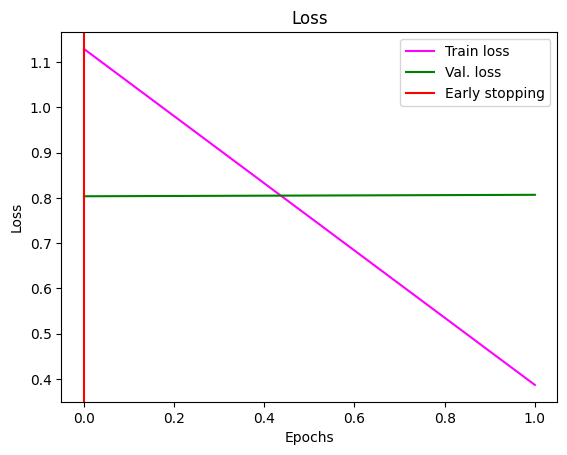

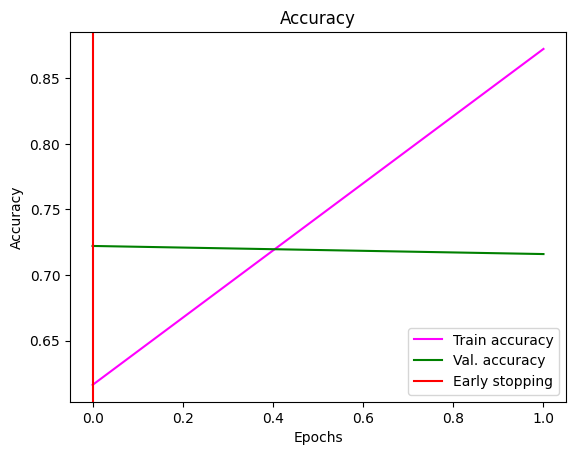

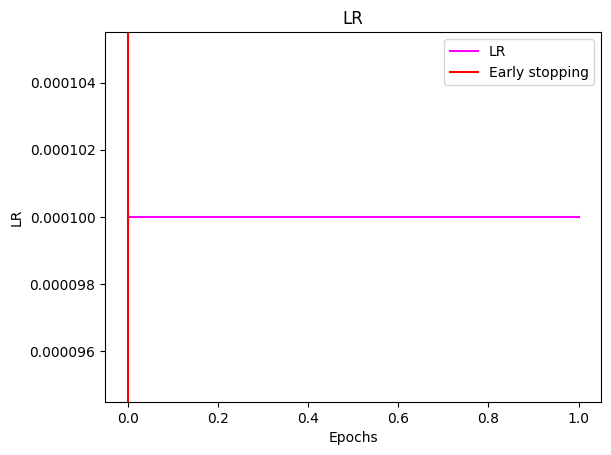

In [ ]:
if TRAIN:
    # List with the epoch indices. [0, 1, ... num_epochs - 1]
    epochs_list = []
    for i in range(len(train_loss_list)):
        epochs_list.append(i)

    # Plot - Loss 
    fig_obj = plt.figure()

    plt.title('Loss')
    plt.plot(epochs_list, train_loss_list, c='magenta', label='Train loss', fillstyle='none')
    plt.plot(epochs_list, val_loss_list, c='green', label='Val. loss', fillstyle='none')
    if args.es:
        plt.axvline(x=early_stopping.best_epoch, color='r', label='Early stopping')
        ### plt.text(early_stopping.best_epoch + 0.1, (-early_stopping.best_score) + .05, str(f'{-early_stopping.best_score:.4f}'), color = 'blue', fontweight = 'bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='best')

    # Saves the figure to disk
    plt.savefig(os.path.join(EXP_PATH, 'chart_loss.png'))
    plt.savefig(os.path.join(EXP_PATH, 'chart_loss.pdf')) 

    # Plot - Accuracy
    fig_obj = plt.figure()

    plt.title('Accuracy')
    plt.plot(epochs_list, train_acc_list, c='magenta', label='Train accuracy', fillstyle='none')
    plt.plot(epochs_list, val_acc_list, c='green', label='Val. accuracy', fillstyle='none')
    if args.es:
        plt.axvline(x=early_stopping.best_epoch, color='r', label='Early stopping')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')

    # Saves the figure to disk
    plt.savefig(os.path.join(EXP_PATH, 'chart_acc.png')) 
    plt.savefig(os.path.join(EXP_PATH, 'chart_acc.pdf')) 

    # Plot LR
    fig_obj = plt.figure()

    plt.title('LR')
    plt.plot(epochs_list, lr_list, c='magenta', label='LR', fillstyle='none')
    if args.es:
        plt.axvline(x=early_stopping.best_epoch, color='r', label='Early stopping')
    plt.xlabel('Epochs')
    plt.ylabel('LR')
    plt.legend(loc='best')

    # Saves the figure to disk
    plt.savefig(os.path.join(EXP_PATH, 'chart_lr.png')) 
    plt.savefig(os.path.join(EXP_PATH, 'chart_lr.pdf')) 

### Saving trainning report

In [ ]:
if TRAIN:
    # CSV file that will store all losses and accuracies.
    report_filename = os.path.join(EXP_PATH, 'training_report' + '.csv')
    # Creates the CSV file
    report_file = open(report_filename, 'w')

    header = 'Epoch;Train Loss;Val. Loss;Train Acc.;Val. Acc.\n'
    report_file.write(header)

    # Putting values from each epoch inside of archive
    for i in range(0, len(train_loss_list)):
        text = str(i) + ';' + str(train_loss_list[i]) + ';' + str(val_loss_list[i]) + ';' + str(train_acc_list[i]) + ';' + str(val_acc_list[i]) + ';' + str(lr_list[i]) 
        if args.es and i == early_stopping.best_epoch:
            text += '; *\n'
        else:
            text += '\n'

        report_file.write(text)

    if args.es:
        report_file.write(f'Early stopping: ; {early_stopping.best_epoch}')

    # Closes the file
    report_file.close()

## Evaluating the model
---

In [ ]:
def eval_model(mode='val'): 
    # Enables the model for evaluation
    model.eval()

    # Lists with the true classes ('true'), the classes predicted by the model ('pred'), and the paths for each image (path).
    true_list = []
    pred_list = []
    path_list = []

    prob_list = []

    # Starts the time counting.
    time_start = time.time()

    # Select the appropriate dataloader.
    if mode == 'val':
        dataloader = dataloader_val
    elif mode == 'test':
        dataloader = dataloader_test

    # Iterates over the dataloader.
    # -----------------------------
    for i, (img_batch, true_batch, path_batch) in enumerate(dataloader):
        # Sends the data to the GPU
        img_batch = img_batch.to(DEVICE)
        true_batch = true_batch.to(DEVICE)

        # So that the gradient does not update!
        torch.set_grad_enabled(False)

        # Model output
        outputs = model(img_batch) 

        if num_classes == 2 and args.bce:
            # Calculate probabilities
            # https://discuss.pytorch.org/t/bceloss-vs-bcewithlogitsloss/33586/27
            outputs_prob = torch.sigmoid(outputs) 
            preds = (outputs_prob > 0.5).float().squeeze()

            # We have the probability of class 0. Probability of class 0 is (1 - prob(c_1))
            prob_batch = np.asarray(outputs_prob.cpu())
            prob_batch = np.c_[1. - prob_batch, prob_batch]

        else:
            preds = torch.argmax(outputs, dim=1)

            # https://discuss.pytorch.org/t/obtain-probabilities-from-cross-entropy-loss/157259
            outputs_prob = nn.functional.softmax(outputs, dim=1)

            prob_batch = np.asarray(outputs_prob.cpu())

        # List of the ground truth labels
        true_batch = np.asarray(true_batch.cpu())
        # List of prediction labels
        pred_batch = np.asarray(preds.cpu(), dtype=int)
        # List with the image paths
        path_batch = list(path_batch)

        # Consolidates the prediction and ground truth lists
        for i in range(0, len(pred_batch)):
            true_list.append(true_batch[i])
            pred_list.append(pred_batch[i])
            path_list.append(path_batch[i])

            prob_list.append(prob_batch[i])

    # Calculates the total test time
    time_total = time.time() - time_start

    return path_list, true_list, pred_list, prob_list, time_total

In [784]:
path_val_list, true_val_list, pred_val_list, prob_val_list, time_total_val = eval_model('val')
path_test_list, true_test_list, pred_test_list, prob_test_list, time_total_test = eval_model('test')

### Set the prediction folder

In [785]:
EXP_PATH_PRED = os.path.join(EXP_PATH, f'PRED-dstest_{args.ds_test}')

# Check if EXP_PATH_PRED exists. If not, create it.
if not os.path.exists(EXP_PATH_PRED):
    os.mkdir(EXP_PATH_PRED)

if os.path.exists(os.path.join(EXP_PATH_PRED, 'done.txt')):
    # The folder exists and the experiment is done.
    print('Prediction is already done! Exiting...')

    sys.exit()

### Confusion matrix and classification reports (scikit-learn)

In [ ]:
def gen_reports(mode='val'):
    if mode=='val':
        # Confusion matrix
        conf_mat = metrics.confusion_matrix(true_val_list, pred_val_list, 
                                            labels=list(range(len(class_names))))
        # Classification report - Scikit-learn
        class_rep = metrics.classification_report(true_val_list, pred_val_list, 
                                                  target_names=class_names, 
                                                  labels=list(range(len(class_names))),
                                                  digits=4)
        # Accuracy
        acc = metrics.accuracy_score(true_val_list, pred_val_list)

        precision_m, recall_m, f1_m, _ = metrics.precision_recall_fscore_support(true_val_list, pred_val_list, average='macro')
        precision_w, recall_w, f1_w, _ = metrics.precision_recall_fscore_support(true_val_list, pred_val_list, average='weighted')

    elif mode=='test':
        # Confusion matrix
        conf_mat = metrics.confusion_matrix(true_test_list, pred_test_list,
                                            labels=list(range(len(class_names))),)
        # Classification report - Scikit-learn
        class_rep = metrics.classification_report(true_test_list, pred_test_list, 
                                                  target_names=class_names, 
                                                  labels=list(range(len(class_names))),
                                                  digits=4)
        # Accuracy
        acc = metrics.accuracy_score(true_test_list, pred_test_list)

        precision_m, recall_m, f1_m, _ = metrics.precision_recall_fscore_support(true_test_list, pred_test_list, average='macro')
        precision_w, recall_w, f1_w, _ = metrics.precision_recall_fscore_support(true_test_list, pred_test_list, average='weighted')


    class_rep_path = os.path.join(EXP_PATH_PRED, f'classification_report_{mode}.txt')
    file_rep = open(class_rep_path, 'w')

    file_rep.write(f'\n\n{mode.upper()} SET:')
    file_rep.write('\n---------------')
    file_rep.write('\nConfusion matrix:\n')
    file_rep.write(str(conf_mat))
    file_rep.write('\n')
    file_rep.write('\nClassification report:\n')
    file_rep.write(class_rep)
    file_rep.write('\n')
    file_rep.write('\nAccuracy: ' + str(acc))

    file_rep.close()

    # Define a scaling factor
    num_classes_os = len(class_names)
    ### fig_size = max(8, num_classes_os * 0.6)  # Adjust size dynamically, min size of 8
    fig_size = 8
    print(fig_size)   

    plt.figure(figsize=(fig_size, fig_size))  # Set figure size dynamically
    disp = metrics.ConfusionMatrixDisplay(conf_mat, display_labels=class_names)
    disp.plot(cmap='viridis')

    if num_classes_os >= 16:
        factor = 1. / (num_classes_os / 16)
    else:
        factor = 1.

    # Rotate x-axis labels and align properly
    plt.xticks(rotation=45, ha='right', fontsize=fig_size * factor)   
    plt.yticks(fontsize=fig_size * factor)  # Adjust Y-axis font
    # Adjust the size of the values inside the matrix
    for text in plt.gca().texts:
        text.set_fontsize(fig_size * factor)  # Increase the font size of the numbers inside the matrix
    ### plt.show()

    # Adjust the layout to avoid label clipping
    plt.tight_layout()

    # Save figure in disk
    plt.savefig(os.path.join(EXP_PATH_PRED, f'conf_mat_{mode}.png')) 
    plt.savefig(os.path.join(EXP_PATH_PRED, f'conf_mat_{mode}.pdf')) 

    print(conf_mat)
    print(class_rep)
    print(f'{mode.upper()} Acc.: {acc:.4f}')

    return acc, class_rep_path, precision_m, recall_m, f1_m, precision_w, recall_w, f1_w

/home/joao/anaconda3/envs/env-coffee-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/joao/anaconda3/envs/env-coffee-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/joao/anaconda3/envs/env-coffee-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

8
[[  5   0   9   1   8   0   0   0]
 [  2   1  19   1   1   0   0   4]
 [  0   1  48   1   3   0   0   1]
 [  3   0   0 135   0   0   2   3]
 [  0   1   3   2  50   0   0   0]
 [  0   0   1   3   2   0   0   0]
 [  0   0   1   3   1   0  11  11]
 [  0   3  13  20   0   0  12 101]]
                  precision    recall  f1-score   support

       ascochyta     0.5000    0.2174    0.3030        23
bacterial_blight     0.1667    0.0357    0.0588        28
      cercospora     0.5106    0.8889    0.6486        54
         healthy     0.8133    0.9441    0.8738       143
           miner     0.7692    0.8929    0.8264        56
           phoma     0.0000    0.0000    0.0000         6
 red_spider_mite     0.4400    0.4074    0.4231        27
            rust     0.8417    0.6779    0.7509       149

        accuracy                         0.7222       486
       macro avg     0.5052    0.5080    0.4856       486
    weighted avg     0.7004    0.7222    0.6959       486

VAL Acc.: 0.7222
8

/home/joao/anaconda3/envs/env-coffee-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/joao/anaconda3/envs/env-coffee-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/joao/anaconda3/envs/env-coffee-py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

[[  7   1   8   2  10   0   0   1]
 [  3   1  24   3   2   0   0   3]
 [  0   0  59   1   4   0   0   3]
 [  0   0   0 170   3   0   0   5]
 [  0   0  10   0  59   0   0   1]
 [  2   0   1   5   0   0   0   0]
 [  0   0   0   2   2   0  15  15]
 [  1   0  12  18   3   0  15 137]]
                  precision    recall  f1-score   support

       ascochyta     0.5385    0.2414    0.3333        29
bacterial_blight     0.5000    0.0278    0.0526        36
      cercospora     0.5175    0.8806    0.6519        67
         healthy     0.8458    0.9551    0.8971       178
           miner     0.7108    0.8429    0.7712        70
           phoma     0.0000    0.0000    0.0000         8
 red_spider_mite     0.5000    0.4412    0.4688        34
            rust     0.8303    0.7366    0.7806       186

        accuracy                         0.7368       608
       macro avg     0.5554    0.5157    0.4945       608
    weighted avg     0.7237    0.7368    0.7073       608

TEST Acc.: 0.7368


<Figure size 800x800 with 0 Axes>

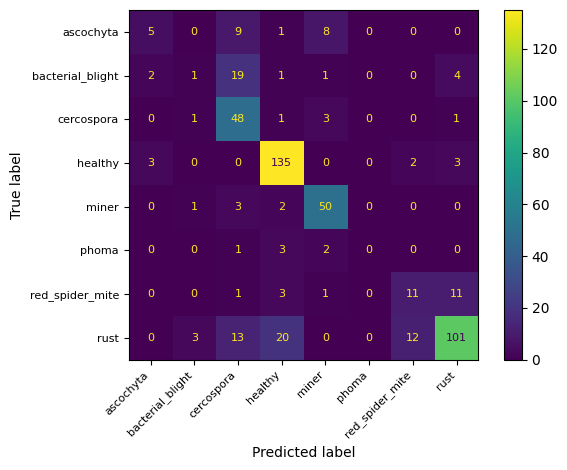

<Figure size 800x800 with 0 Axes>

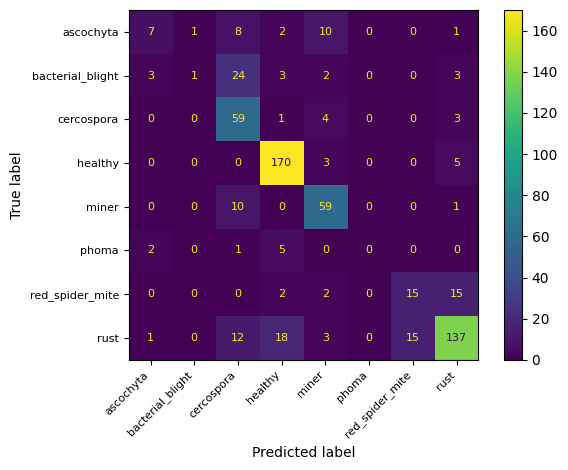

In [787]:
acc_val, _, precision_m_val, recall_m_val, f1_m_val, precision_w_val, recall_w_val, f1_w_val = gen_reports('val')
acc_test, class_rep_test_path, precision_m_test, recall_m_test, f1_m_test, precision_w_test, recall_w_test, f1_w_test = gen_reports('test')

### Classification report

In [ ]:
def class_rep(mode='val'):

    if mode=='val':
        true_list = true_val_list
        pred_list = pred_val_list
        prob_list = prob_val_list
        path_list = path_val_list

    elif mode=='test':
        true_list = true_test_list
        pred_list = pred_test_list
        prob_list = prob_test_list
        path_list = path_test_list

    file_details_path = os.path.join(EXP_PATH_PRED, f'classification_details_{mode}.csv')
    file_details = open(file_details_path, 'w')

    file_details.write(f'{mode.upper()} SET')
    file_details.write('\n#;File path;Target;Prediction')

    for class_name in class_names:
        file_details.write(';' + str(class_name))

    for i, (target, pred, probs) in enumerate(zip(true_list, pred_list, prob_list)):
        image_name = str(path_list[i])
        file_details.write('\n' + str(i) + ';' + image_name + ';' + str(target) + ';' + str(pred))

        for prob in probs:
            file_details.write(';' + str(prob))

    file_details.close()

In [789]:
class_rep('val')
class_rep('test')

In [ ]:
# Calculates the total experiment time.
time_exp_total = time.time() - time_exp_start

### General report (Including hyperparameter optimization)

In [ ]:
if args.optim != 'none':
    print('\n>> Hyperparameter optimization report...')
    # The name of a CSV file. It will store all losses and accuracies.
    # If doing hyperparameter optimization, separate by architecture.
    hp_filename = os.path.join(EXP_PATH_MAIN, '(' + ds_path_str + ')-' + args.arch + '-' + args.optim + '.csv')
else:
    print('\n>> Experiment set report...')
    # No hyperparameter optimization for open-set
    hp_filename = os.path.join(EXP_PATH_MAIN, f'gen_report-{args.optim}.csv')

print(hp_filename)

if args.ec == 0:
    # Creates the CSV file
    hp_file = open(hp_filename, 'w')

    # Creates header for the CSV file
    header = '#;DS;DS_TEST;OVERL;ARCH;HP;FT;DA_TRAIN;DA_VAL;DA_TEST;BS;LR;SCH;MM;SS;EP;ES;ACC_VAL;PREC_M_VAL;REC_M_VAL;F1_M_VAL;PREC_W_VAL;REC_W_VAL;F1_W_VAL;ACC_TEST;PREC_M_TEST;REC_M_TEST;F1_M_TEST;PREC_W_TEST;REC_W_TEST;F1_W_TEST;ACC_TRAIN*;ACC_VAL*;TIME_TRAIN;TIME_VAL;TIME_TEST;TIME_EXP\n'
    hp_file.write(header)

else:
    # Opens the existing CSV file in append mode.
    hp_file = open(hp_filename, 'a')

# Momentum. Only if optmizer is SGD
mm_str = f'{args.mm}' if args.optimizer == 'SGD' else ''
# Step size. Only if scheduler is steplr
ss_str = f'{args.ss}' if args.scheduler == 'steplr' else ''
# Early stopping
es_ = early_stopping.best_epoch if args.es else args.ep - 1

if TRAIN == False:
    train_acc_ = ''
    val_acc_ = ''
else:
    train_acc_ = train_acc_list[early_stopping.best_epoch]
    val_acc_ = val_acc_list[early_stopping.best_epoch]

info = f'{args.ec};{ds_path_str};{ds_path_test_str};{ov_str};' + \
       f'{args.arch};{args.optim};{args.ft};{args.datrain};{args.daval};{args.datest};' + \
       f'{args.bs};{args.lr};{args.scheduler};' + \
       f'{mm_str};{ss_str};' + \
       f'{args.ep};{es_};' + \
       f'{acc_val};{precision_m_val};{recall_m_val};{f1_m_val};{precision_w_val};{recall_w_val};{f1_w_val};' + \
       f'{acc_test};{precision_m_test};{recall_m_test};{f1_m_test};{precision_w_test};{recall_w_test};{f1_w_test};' + \
       f'{train_acc_};{val_acc_};' + \
       f'{str(datetime.timedelta(seconds=time_total_train))};{str(datetime.timedelta(seconds=time_total_val))};' + \
       f'{str(datetime.timedelta(seconds=time_total_test))};{str(datetime.timedelta(seconds=time_exp_total))}\n'

hp_file.write(info)

hp_file.close()


>> Relatório do conjunto de experimentos...
exp_debug/gen_report-none.csv


## Done!
---

In [ ]:
# If the file "done.txt" is in the folder, the experiment finished successfully!
done_file = open(os.path.join(EXP_PATH, 'done.txt'), 'w')
done_file.close()

done_file = open(os.path.join(EXP_PATH_PRED, 'done.txt'), 'w')
done_file.close()

print('\nDone!\n\n')


Done!


